# Tournament analysis (260715): which models win in competition

Analyses the selfless-model tournament in `~/Unity/Octagon/simulations/tournaments/260715` (see [[octagon-tournament]] memory). 8 models, every ordered pair with mirrors plus self-matchups = **64 matchups**. Folder `260715_00A__vs__260715_00B` means model A drives agent 0 (P1), model B drives agent 1 (P2). Each trial is winner-take-all: the winner scores **1.0** (reached High) or **0.4** (reached Low), the loser 0.

**Goal:** which models are most successful in competition, using **player score over time** (accumulated player score) as the metric each agent is trying to maximise. Then whether the *interaction* of models (a specific pairing) matters beyond each model's general strength.

All extraction, statistics and figures come from `analysis/tournament_analysis.py`, shared with every other tournament batch; this notebook holds the config and the written-up results.

**This notebook covers**
1. **Run validation** — are the matchups complete and fair (self-matchups near 50%, mirror-consistent)? 
2. **Per-run results + head-to-head matrices** — the outcome of each matchup; raw score and win-rate matrices for reference.
3. **Overall ranking** — mean score per trial, total accumulated score, win rate, and a Bradley-Terry strength, per model.
4. **Pair interaction** — how much each head-to-head deviates from what the models' overall strengths predict (Bradley-Terry residual), plus a non-transitivity check for rock-paper-scissors loops.

Situational breakdowns (per wall separation) and behavioural strategy characterisation are left to a separate notebook.

> **Data note.** Run after the tournament finishes (every matchup has `DONE.txt`). The validation cell will flag any incomplete or unfair matchups.

> **Build note.** The tournament was run with `build_260724_01_tournament`, which has the no-movement penalty-break **absent** (every step penalised) — this does *not* match the training build (`260715_01_social`, break present). It does **not** affect this analysis: at inference the policy is fixed, so the step penalty changes only the logged **reward**, never who wins or the player **scores** used here. It would only matter for a reward-based analysis (see `tournament_analysis_demo_2`).

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import analysis.tournament_analysis as ta

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

BASE = os.path.expanduser('~/Unity/Octagon/simulations/tournaments/260715')

# entrants and their strategy band, from the model characterisation notebook. Dict order
# sets the row/column order of every matrix and the legend order, so keep the models
# ordered within a band the way you want them read (here: most extreme first).
STRATEGY = {22: 'central', 20: 'central', 2: 'central',
            14: 'intermediate', 10: 'intermediate',
            36: 'peripheral', 15: 'peripheral', 26: 'peripheral'}
MODELS = ta.models_in_order(STRATEGY)      # grouped by band, in the order above

## Main pass — load every matchup

Loads each of the 64 matchups (~5 s each), extracts per-trial outcomes, and stacks them into one long table. Also reports which matchups are missing `DONE.txt`.

In [2]:
# One row per completed trial per matchup: both models, the winning client, each model's
# score and reward, and the wall separation. ~5 s per matchup.
trials_df = ta.load_tournament(BASE)
per_matchup = ta.per_matchup_summary(trials_df)

# One row per (focus model, opponent) per trial, so both seat orders pool. Self-matchups
# are dropped — a model cannot out-rank itself. Every trial appears twice, once framed from
# each model's side, so ALWAYS index this table by `focus`.
selfless = ta.perspective_table(trials_df)

260715_0002__vs__260715_0002 done  

260715_0002__vs__260715_0010 done  

260715_0002__vs__260715_0014 done  

260715_0002__vs__260715_0015 done  

260715_0002__vs__260715_0020 done  

...

260715_0036__vs__260715_0015 done  

260715_0036__vs__260715_0020 done  

260715_0036__vs__260715_0022 done  

260715_0036__vs__260715_0026 done  

260715_0036__vs__260715_0036 done  

matchups loaded: 64 / 64   trials: 22312
trials per matchup: min 342, max 349


## 1. Run validation

Before trusting any ranking, confirm the tournament is fair:
- **Self-matchups** (a model vs a copy of itself) should sit near **0.5** — far from it means a seat/agent asymmetry (the failure mode of the first run, where the opponent never moved).
- **Mirror consistency** — a model's win rate against an opponent should be the same whether it played P1 or P2. Large gaps mean seat still matters.
- **Winner-take-all** — exactly one agent scores each trial.

It is important to note that we can use score instead of reward here, because we are only comparing self-matchups, and the mirror matchups. Therefore score proportions should not differ in these comparisons (but should in comparisons of non-self, non-mirror matchups)

In [3]:
ta.validation_report(trials_df, per_matchup, MODELS);

Self-matchup P1 win rate (should be ~0.5):
 model   n  p1_win_rate
     2 349        0.550
    10 342        0.520
    14 349        0.527
    15 349        0.510
    20 349        0.562
    22 349        0.567
    26 349        0.481
    36 349        0.484
  mean 0.525, worst deviation from 0.5: 0.067

Mirror consistency over 28 pairs — mean gap 0.018, max 0.066
    pair  A_asP1  A_asP2   gap
 22 vs 2   0.605   0.539 0.066
22 vs 26   0.691   0.650 0.040
 2 vs 14   0.579   0.616 0.037
15 vs 26   0.504   0.476 0.029
 2 vs 15   0.756   0.782 0.026

winner-take-all (exactly one agent scores per trial): 1.000 of trials
reward range: [-0.988, 0.949]  (negative = moved and lost)


## 2. Per-run results and head-to-head

Each matchup's outcome, then the pooled head-to-head matrices. Pooling both seat orders (A-vs-B and B-vs-A) gives a seat-balanced estimate of how each model does against each opponent. (Though see above for validation on seat being independent of competitive success)

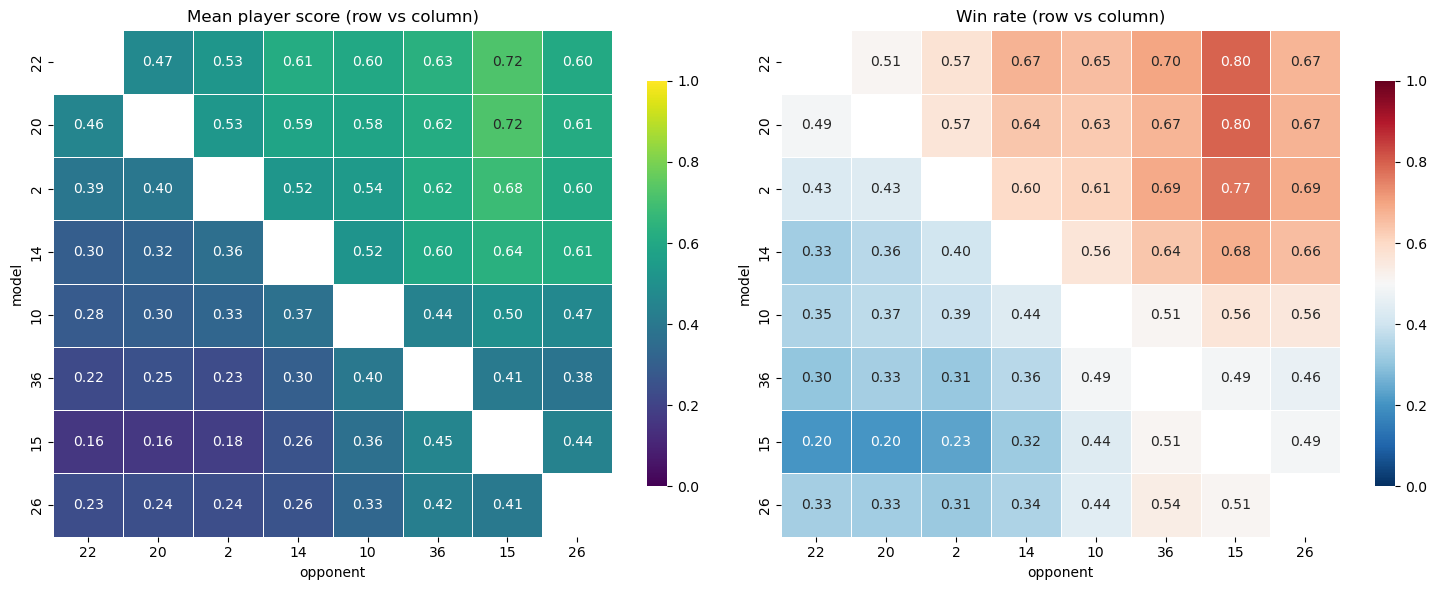

Per-matchup results (ordered A=P1 vs B=P2):


,matchup,model_A,model_B,n,p1_win_rate,mean_score_A,mean_score_B,mean_reward_A,mean_reward_B
0,260715_0002__vs__260715_0002,2,2,349,0.550,0.505,0.402,0.049,-0.054
1,260715_0002__vs__260715_0010,2,10,348,0.615,0.553,0.314,0.104,-0.135
2,260715_0002__vs__260715_0014,2,14,349,0.579,0.507,0.378,0.054,-0.074
3,260715_0002__vs__260715_0015,2,15,349,0.756,0.676,0.189,0.226,-0.261
4,260715_0002__vs__260715_0020,2,20,349,0.438,0.413,0.529,-0.041,0.075
...,...,...,...,...,...,...,...,...,...
59,260715_0036__vs__260715_0015,36,15,349,0.496,0.420,0.446,-0.043,-0.017
60,260715_0036__vs__260715_0020,36,20,349,0.318,0.248,0.629,-0.195,0.186
61,260715_0036__vs__260715_0022,36,22,349,0.292,0.215,0.639,-0.226,0.198
62,260715_0036__vs__260715_0026,36,26,348,0.474,0.395,0.428,-0.062,-0.030


In [4]:
# Mirror-pooled matrices, read row-model against column-opponent.
mats = ta.head_to_head(selfless, MODELS)
ta.plot_head_to_head(mats)
plt.show()

print("Per-matchup results (ordered A=P1 vs B=P2):")
per_matchup.round(3)

## 3. Overall ranking

Which models are most successful, over all opponents (self-matchups excluded). The focus is **mean score per trial** (which is close to the reward over time that agents are maximising); total accumulated score and win rate are also used, plus a Bradley-Terry strength fit from the win/loss counts.

Overall ranking by mean score:
 rank  model     strategy  mean_score  total_score  win_rate  bt_strength
    1     22      central       0.596       2911.2     0.653        1.624
    2     20      central       0.586       2861.6     0.638        1.532
    3      2      central       0.537       2622.2     0.602        1.335
    4     14 intermediate       0.478       2333.8     0.519        0.982
    5     10 intermediate       0.383       1867.0     0.453        0.771
    6     36   peripheral       0.313       1525.6     0.391        0.614
    7     26   peripheral       0.303       1478.0     0.400        0.634
    8     15   peripheral       0.288       1404.6     0.342        0.507


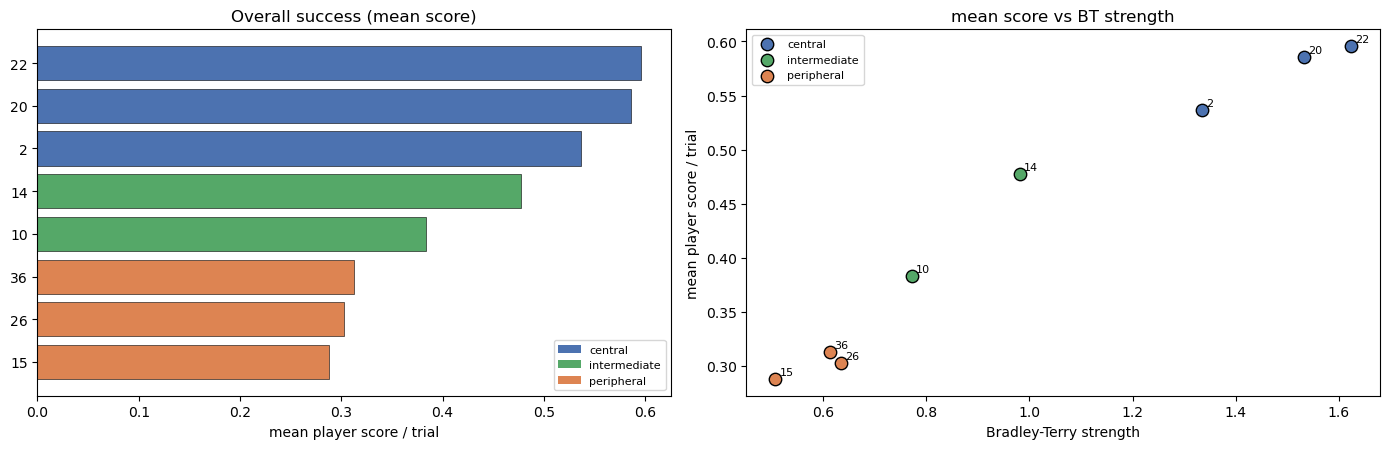

In [5]:
overall = ta.overall_ranking(selfless, STRATEGY, MODELS, sort_by='mean_score')
ta.plot_overall_ranking(overall, metric='mean_score')
plt.show()

## 4. Does the pairing matter? (interaction)

If success were purely each model's general strength, every head-to-head would be predicted by the two Bradley-Terry strengths. The **residual** (actual win rate minus BT-predicted) is the part explained by the specific pairing — the interaction. Large residuals, or non-transitive loops (A beats B beats C beats A), mean the matchup itself matters, not just overall strength.

Interaction (actual - BT-predicted win rate): RMS residual 0.034, max |residual| 0.059
Non-transitive triples (rock-paper-scissors loops): 0 of 56


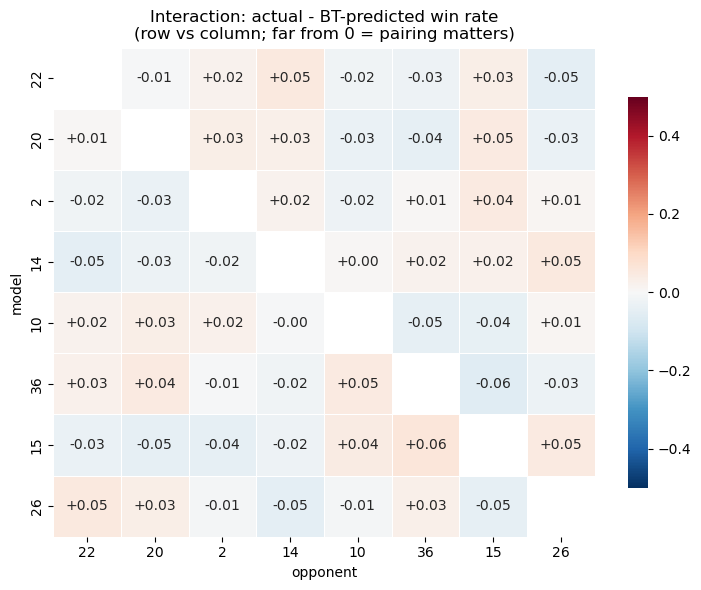

In [6]:
bt = ta.bradley_terry(selfless, MODELS)
resid = ta.interaction(mats['win'], bt, MODELS, strategy=STRATEGY)
ta.plot_interaction(resid)
plt.show()

## Reading the results

- **Validation** — trust the rest only if self-matchups sit near 0.5 and mirror gaps are small. A self-matchup far from 0.5 means the run is still unfair (as in the first, opponent-frozen run).
- **Overall ranking** — mean score per trial (representative of score over time); BT strength should track it closely. Colour shows whether a strategy band (central / intermediate / peripheral) dominates.
- **Interaction** — a small RMS residual and no non-transitive loops means success is essentially each model's general strength, and the pairing adds little. Large residuals or loops mean specific matchups (and strategy clashes) matter beyond overall strength.
- Score is winner-take-all, so a model's mean score combines how often it wins and whether it wins High vs Low; the win-rate matrix is used to separate this out

Situational analysis (per wall separation) and behavioural strategy characterisation are deliberately left to a separate notebook.

Notes for further analysis:

- in these models, and in the strategy in general, peripheral can be more stationary in the ITI (0.6-0.9 compared to 0.15-0.36) (FOR PENALTY BREAK BUILDS, so check this is indeed true)
- Wall sep analysis
- Considerations of 'energy' for turning and movement